## A geodatabase with tables created with Genreate Near Table tool, with distances to all k. Point layers don't matter, that was just experimentation

In [2]:
import pyogrio

gdb = r"E:\World Bank deliverbale 1\knn\New File Geodatabase.gdb"

print(pyogrio.list_layers(gdb))

[['_5_nearest_neighbors' None]
 ['_10_nearest_neighbors' None]
 ['_20_nearest_neighbors' None]
 ['_40_nearest_neighbors' None]
 ['_80_nearest_neighbors' None]
 ['SJ_10m' 'Point']
 ['SJ_20m' 'Point']
 ['SJ_40m' 'Point']
 ['SJ_60m' 'Point']
 ['SJ_80m' 'Point']
 ['SJ_100m' 'Point']
 ['SJ_300m' 'Point']]


# Cell 1 Setup

In [3]:
import os
import pyogrio
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------------------------------------
# INPUTS
# -------------------------------------------------------------------
gdb = r"E:\World Bank deliverbale 1\knn\New File Geodatabase.gdb"
knn_folder = r"E:\World Bank deliverbale 1\knn"

summary_csv_folder = os.path.join(knn_folder, "summary_csvs")
plot_folder = os.path.join(knn_folder, "exploratory_plots")

os.makedirs(summary_csv_folder, exist_ok=True)
os.makedirs(plot_folder, exist_ok=True)

k_values = [5, 10, 20, 40, 80]

print("GDB:", gdb)
print("Summary folder:", summary_csv_folder)
print("Plot folder:", plot_folder)

GDB: E:\World Bank deliverbale 1\knn\New File Geodatabase.gdb
Summary folder: E:\World Bank deliverbale 1\knn\summary_csvs
Plot folder: E:\World Bank deliverbale 1\knn\exploratory_plots


# Cell 2 — Read one table as a test

In [4]:
test_layer = "_5_nearest_neighbors"

df_test = pyogrio.read_dataframe(gdb, layer=test_layer)

print(df_test.shape)
print(df_test.columns.tolist())
df_test.head()

(2891895, 8)
['IN_FID', 'NEAR_FID', 'NEAR_DIST', 'NEAR_RANK', 'FROM_X', 'FROM_Y', 'NEAR_X', 'NEAR_Y']


,IN_FID,NEAR_FID,NEAR_DIST,NEAR_RANK,FROM_X,FROM_Y,NEAR_X,NEAR_Y
0,1,258630,15.893942,1,344402.3876,536236.5269,344387.1014,536240.8800
1,1,443611,17.243420,2,344402.3876,536236.5269,344405.2765,536253.5266
2,1,572149,23.982673,3,344402.3876,536236.5269,344425.9653,536240.9156
3,1,151381,24.235041,4,344402.3876,536236.5269,344387.2062,536217.6361
4,1,187746,24.751932,5,344402.3876,536236.5269,344385.6412,536254.7537


# Cell 3 — Create one summary CSV per nearest neighbor table

In [5]:
summary_csvs = {}

for k in k_values:
    layer = f"_{k}_nearest_neighbors"
    print("\n" + "=" * 70)
    print(f"Processing {layer}")

    df = pyogrio.read_dataframe(gdb, layer=layer)

    print("Rows:", f"{len(df):,}")
    print("Columns:", df.columns.tolist())

    required = ["IN_FID", "NEAR_DIST", "NEAR_RANK"]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"{layer} is missing required columns: {missing}")

    # Keep only needed columns for distance summary
    small = df[["IN_FID", "NEAR_DIST", "NEAR_RANK"]].copy()

    # Force numeric, just in case
    small["IN_FID"] = pd.to_numeric(small["IN_FID"], errors="coerce")
    small["NEAR_DIST"] = pd.to_numeric(small["NEAR_DIST"], errors="coerce")
    small["NEAR_RANK"] = pd.to_numeric(small["NEAR_RANK"], errors="coerce")

    # Drop rows with missing IDs or distances
    small = small.dropna(subset=["IN_FID", "NEAR_DIST"])

    # Summary by target building
    summary = (
        small
        .groupby("IN_FID", as_index=False)
        .agg(
            **{
                f"neighbor_count_k{k}": ("NEAR_DIST", "count"),
                f"mean_dist_k{k}": ("NEAR_DIST", "mean"),
                f"median_dist_k{k}": ("NEAR_DIST", "median"),
                f"min_dist_k{k}": ("NEAR_DIST", "min"),
                f"dist_to_{k}th_neighbor": ("NEAR_DIST", "max"),
                f"std_dist_k{k}": ("NEAR_DIST", "std"),
                f"max_near_rank_k{k}": ("NEAR_RANK", "max"),
            }
        )
        .rename(columns={"IN_FID": "building_id"})
    )

    # Optional: flag cases where fewer than k neighbors were returned
    summary[f"complete_k{k}"] = summary[f"neighbor_count_k{k}"] == k

    out_csv = os.path.join(summary_csv_folder, f"knn_summary_k{k}.csv")
    summary.to_csv(out_csv, index=False)

    summary_csvs[k] = out_csv

    print("Summary rows:", f"{len(summary):,}")
    print("Complete rows:", f"{summary[f'complete_k{k}'].sum():,}")
    print("Exported:", out_csv)

print("\nDone.")


Processing _5_nearest_neighbors
Rows: 2,891,895
Columns: ['IN_FID', 'NEAR_FID', 'NEAR_DIST', 'NEAR_RANK', 'FROM_X', 'FROM_Y', 'NEAR_X', 'NEAR_Y']
Summary rows: 578,379
Complete rows: 578,379
Exported: E:\World Bank deliverbale 1\knn\summary_csvs\knn_summary_k5.csv

Processing _10_nearest_neighbors
Rows: 5,783,790
Columns: ['IN_FID', 'NEAR_FID', 'NEAR_DIST', 'NEAR_RANK', 'FROM_X', 'FROM_Y', 'NEAR_X', 'NEAR_Y']
Summary rows: 578,379
Complete rows: 578,379
Exported: E:\World Bank deliverbale 1\knn\summary_csvs\knn_summary_k10.csv

Processing _20_nearest_neighbors
Rows: 11,567,580
Columns: ['IN_FID', 'NEAR_FID', 'NEAR_DIST', 'NEAR_RANK', 'FROM_X', 'FROM_Y', 'NEAR_X', 'NEAR_Y']
Summary rows: 578,379
Complete rows: 578,379
Exported: E:\World Bank deliverbale 1\knn\summary_csvs\knn_summary_k20.csv

Processing _40_nearest_neighbors
Rows: 23,135,160
Columns: ['IN_FID', 'NEAR_FID', 'NEAR_DIST', 'NEAR_RANK', 'FROM_X', 'FROM_Y', 'NEAR_X', 'NEAR_Y']
Summary rows: 578,379
Complete rows: 578,379
Exp

# Cell 4 — Merge all NN summaries into one wide CSV

In [6]:
wide_df = None

for k in k_values:
    csv_path = summary_csvs[k]
    df = pd.read_csv(csv_path)

    if wide_df is None:
        wide_df = df.copy()
    else:
        wide_df = wide_df.merge(df, on="building_id", how="outer")

wide_csv = os.path.join(summary_csv_folder, "knn_summary_all_k_wide.csv")
wide_df.to_csv(wide_csv, index=False)

print("Wide rows:", f"{len(wide_df):,}")
print("Wide columns:")
print(wide_df.columns.tolist())
print("Exported:", wide_csv)

Wide rows: 578,379
Wide columns:
['building_id', 'neighbor_count_k5', 'mean_dist_k5', 'median_dist_k5', 'min_dist_k5', 'dist_to_5th_neighbor', 'std_dist_k5', 'max_near_rank_k5', 'complete_k5', 'neighbor_count_k10', 'mean_dist_k10', 'median_dist_k10', 'min_dist_k10', 'dist_to_10th_neighbor', 'std_dist_k10', 'max_near_rank_k10', 'complete_k10', 'neighbor_count_k20', 'mean_dist_k20', 'median_dist_k20', 'min_dist_k20', 'dist_to_20th_neighbor', 'std_dist_k20', 'max_near_rank_k20', 'complete_k20', 'neighbor_count_k40', 'mean_dist_k40', 'median_dist_k40', 'min_dist_k40', 'dist_to_40th_neighbor', 'std_dist_k40', 'max_near_rank_k40', 'complete_k40', 'neighbor_count_k80', 'mean_dist_k80', 'median_dist_k80', 'min_dist_k80', 'dist_to_80th_neighbor', 'std_dist_k80', 'max_near_rank_k80', 'complete_k80']
Exported: E:\World Bank deliverbale 1\knn\summary_csvs\knn_summary_all_k_wide.csv


# Cell 5 — Descriptive statistics for distance-to-kth-neighbor

In [7]:
dist_cols = [
    f"dist_to_{k}th_neighbor"
    for k in k_values
    if f"dist_to_{k}th_neighbor" in wide_df.columns
]

desc = wide_df[dist_cols].describe(
    percentiles=[0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
).T

desc_csv = os.path.join(summary_csv_folder, "knn_distance_descriptive_stats.csv")
desc.to_csv(desc_csv)

print("Exported:", desc_csv)
desc

Exported: E:\World Bank deliverbale 1\knn\summary_csvs\knn_distance_descriptive_stats.csv


,count,mean,std,min,1%,5%,10%,25%,50%,75%,90%,95%,99%,max
dist_to_5th_neighbor,578379.0,21.005756,14.568866,2.529629,7.511571,9.648793,10.981038,13.634169,17.504219,23.767875,33.875991,42.672306,71.803592,676.912226
dist_to_10th_neighbor,578379.0,30.828574,20.588203,4.358614,11.586696,14.954135,16.897422,20.541885,25.709107,34.764190,48.929125,60.634604,105.037275,704.784460
dist_to_20th_neighbor,578379.0,44.913175,29.324642,7.188514,17.322235,22.728492,25.763700,30.802196,37.684463,49.861727,69.307967,86.544192,153.465828,844.344195
dist_to_40th_neighbor,578379.0,64.581339,40.870582,16.096692,25.823695,33.987474,38.438728,45.027162,53.838238,70.577827,99.623170,124.175442,221.838779,1119.348143
dist_to_80th_neighbor,578379.0,92.707942,58.166055,23.848991,38.317498,50.005047,56.061332,64.878347,76.872505,100.963016,141.857113,178.048361,328.033336,1356.270495


# Cell 6 — Histograms

Rows used for plotting: 200,000


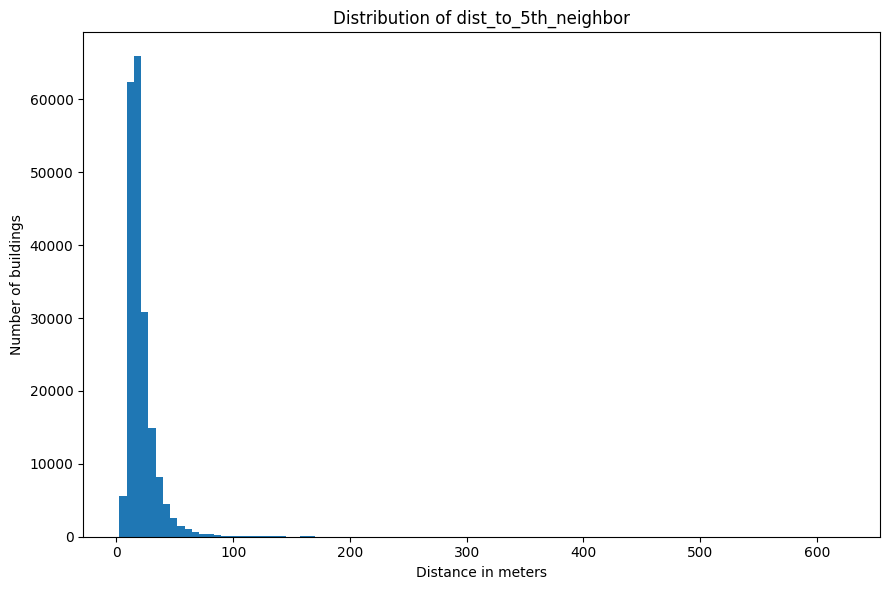

Saved: E:\World Bank deliverbale 1\knn\exploratory_plots\hist_dist_to_5th_neighbor.png


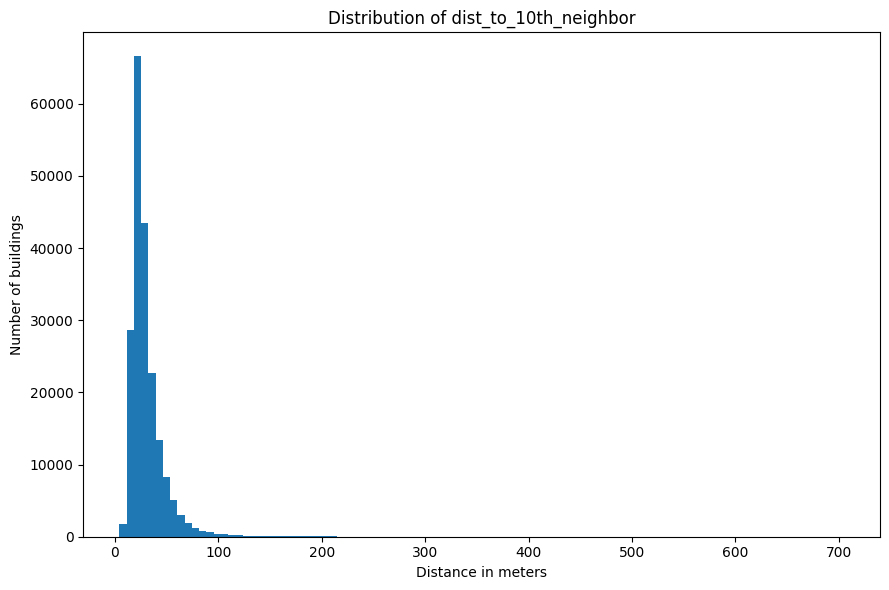

Saved: E:\World Bank deliverbale 1\knn\exploratory_plots\hist_dist_to_10th_neighbor.png


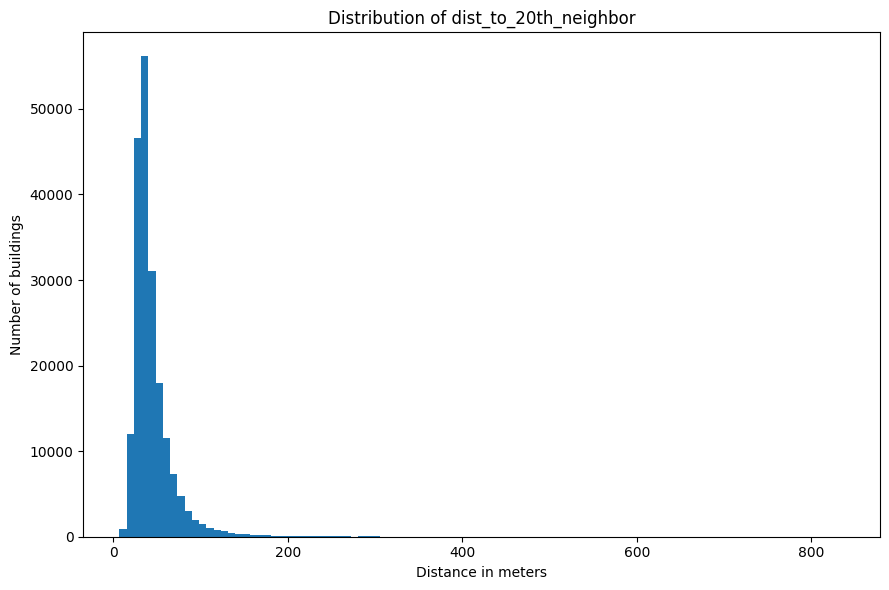

Saved: E:\World Bank deliverbale 1\knn\exploratory_plots\hist_dist_to_20th_neighbor.png


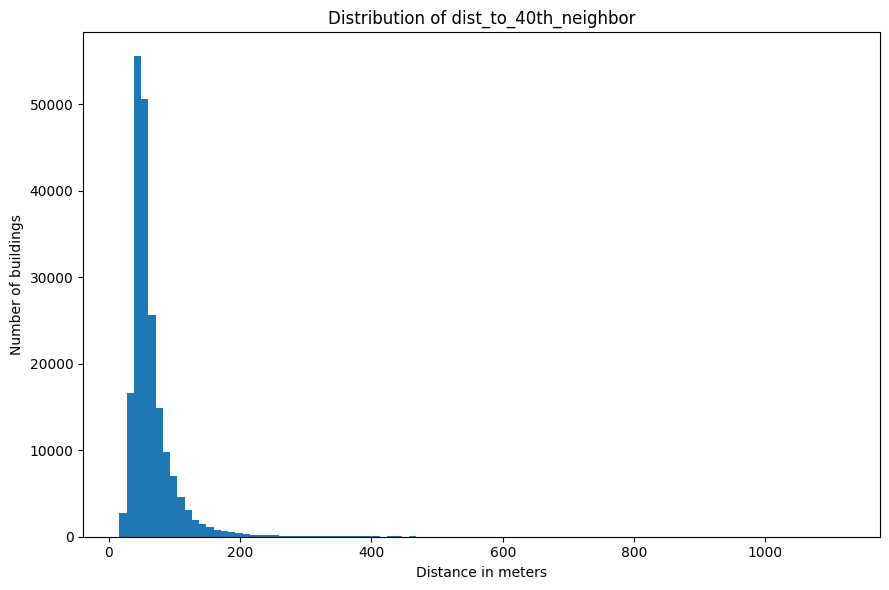

Saved: E:\World Bank deliverbale 1\knn\exploratory_plots\hist_dist_to_40th_neighbor.png


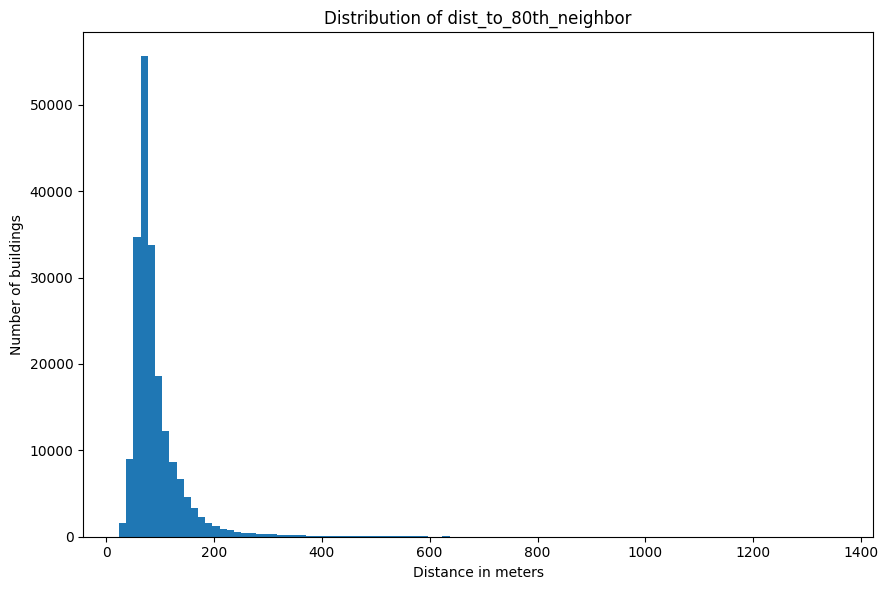

Saved: E:\World Bank deliverbale 1\knn\exploratory_plots\hist_dist_to_80th_neighbor.png


In [8]:
plot_df = wide_df.copy()

sample_size = 200_000
if len(plot_df) > sample_size:
    plot_df_sample = plot_df.sample(sample_size, random_state=42)
else:
    plot_df_sample = plot_df

print("Rows used for plotting:", f"{len(plot_df_sample):,}")

for col in dist_cols:
    vals = plot_df_sample[col].dropna()

    plt.figure(figsize=(9, 6))
    plt.hist(vals, bins=100)
    plt.xlabel("Distance in meters")
    plt.ylabel("Number of buildings")
    plt.title(f"Distribution of {col}")
    plt.tight_layout()

    out_png = os.path.join(plot_folder, f"hist_{col}.png")
    plt.savefig(out_png, dpi=200)
    plt.show()

    print("Saved:", out_png)

# Cell 7 — Histograms with log x-axis

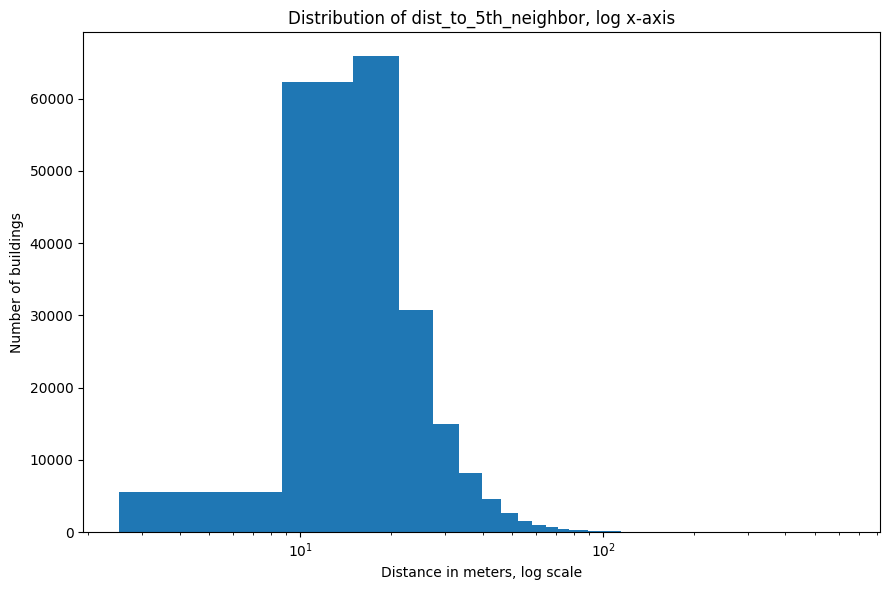

Saved: E:\World Bank deliverbale 1\knn\exploratory_plots\hist_logx_dist_to_5th_neighbor.png


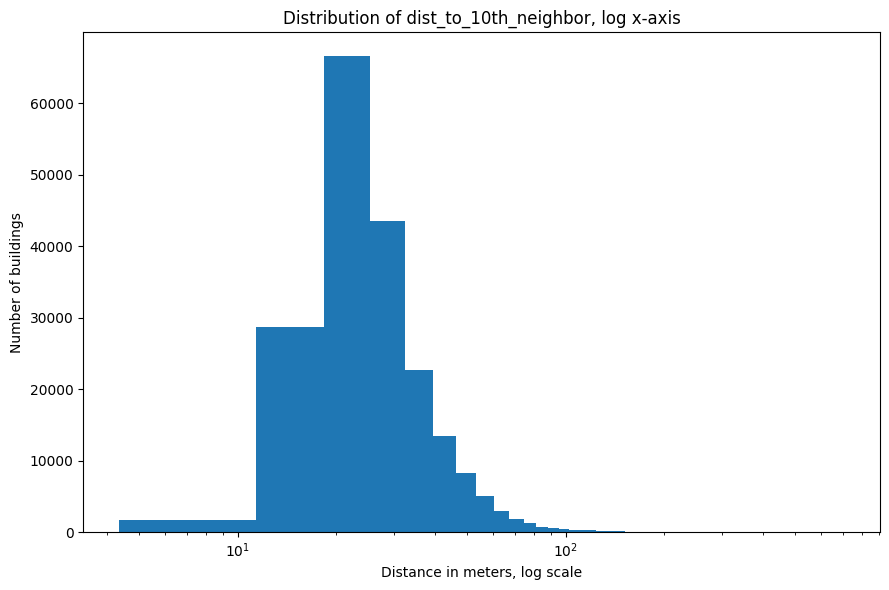

Saved: E:\World Bank deliverbale 1\knn\exploratory_plots\hist_logx_dist_to_10th_neighbor.png


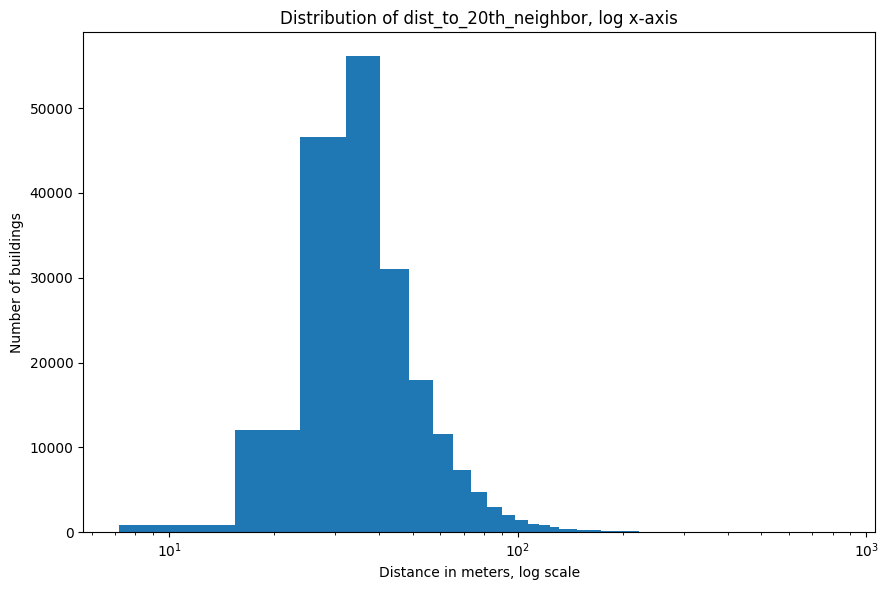

Saved: E:\World Bank deliverbale 1\knn\exploratory_plots\hist_logx_dist_to_20th_neighbor.png


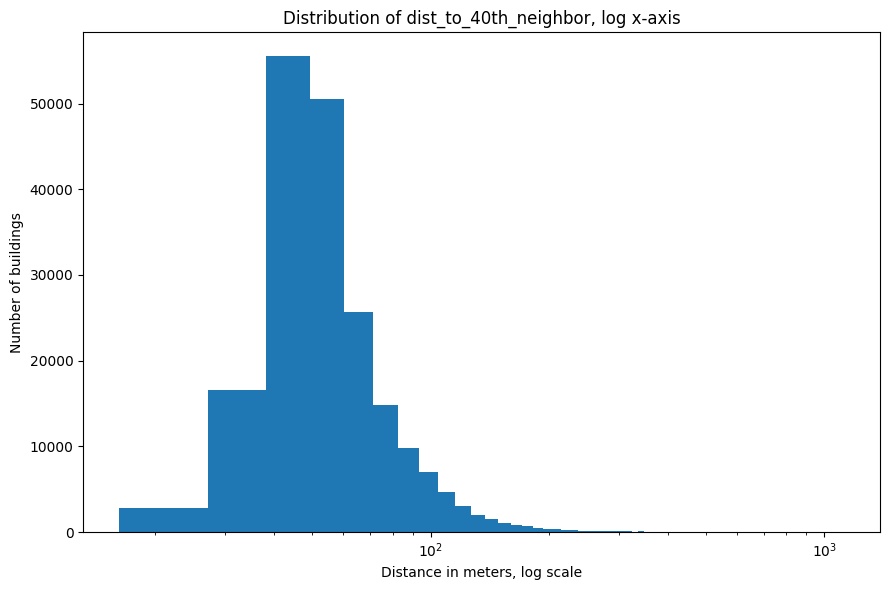

Saved: E:\World Bank deliverbale 1\knn\exploratory_plots\hist_logx_dist_to_40th_neighbor.png


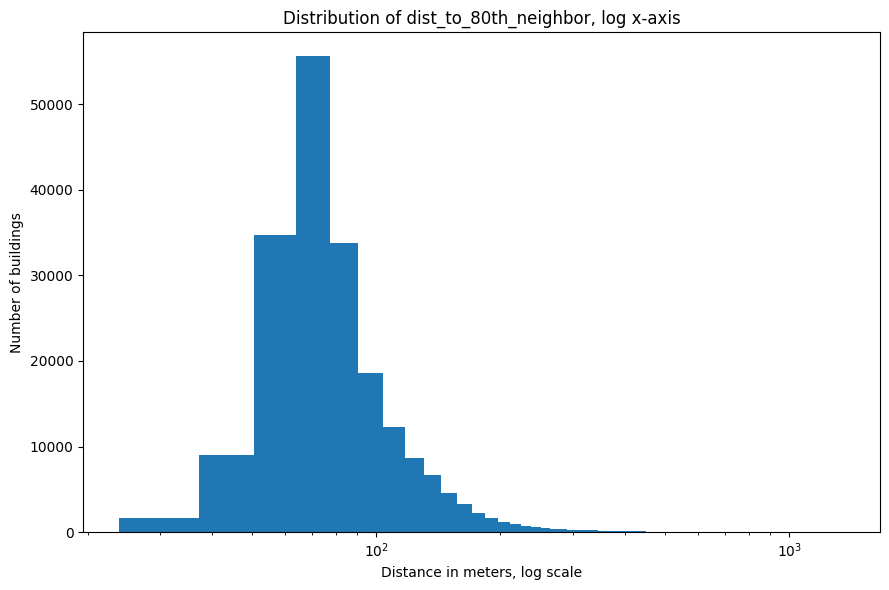

Saved: E:\World Bank deliverbale 1\knn\exploratory_plots\hist_logx_dist_to_80th_neighbor.png


In [9]:
for col in dist_cols:
    vals = plot_df_sample[col].dropna()
    vals = vals[vals > 0]

    plt.figure(figsize=(9, 6))
    plt.hist(vals, bins=100)
    plt.xscale("log")
    plt.xlabel("Distance in meters, log scale")
    plt.ylabel("Number of buildings")
    plt.title(f"Distribution of {col}, log x-axis")
    plt.tight_layout()

    out_png = os.path.join(plot_folder, f"hist_logx_{col}.png")
    plt.savefig(out_png, dpi=200)
    plt.show()

    print("Saved:", out_png)

# Cell 8 — Boxplot comparing the NN distances

C:\Users\Alex Blei\AppData\Local\Temp\ipykernel_21800\1236591638.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(box_data, labels=labels, showfliers=False)


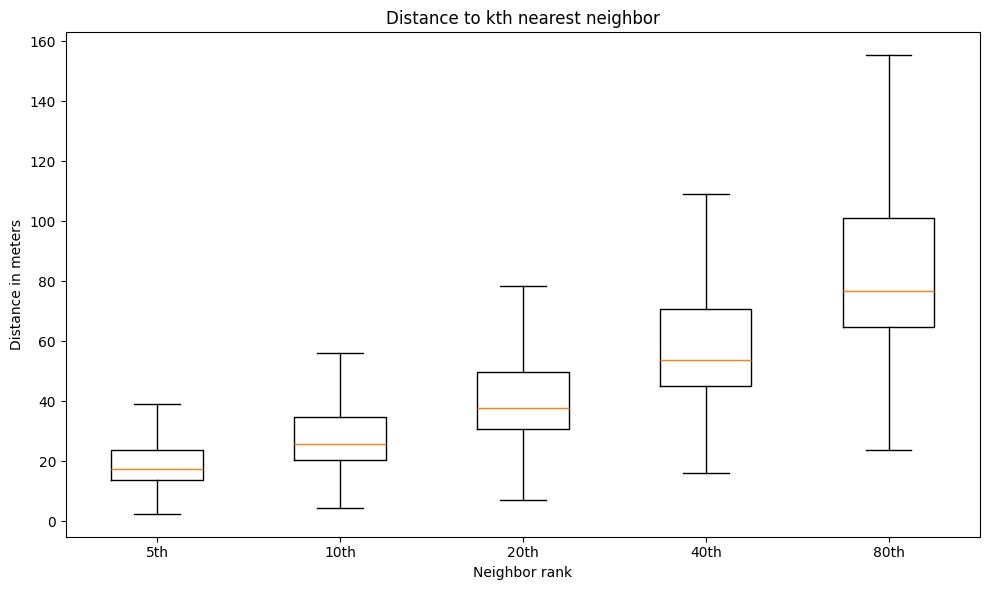

Saved: E:\World Bank deliverbale 1\knn\exploratory_plots\boxplot_distance_to_kth_neighbor.png


In [10]:
box_data = [plot_df_sample[col].dropna() for col in dist_cols]
labels = [col.replace("dist_to_", "").replace("th_neighbor", "th") for col in dist_cols]

plt.figure(figsize=(10, 6))
plt.boxplot(box_data, labels=labels, showfliers=False)
plt.xlabel("Neighbor rank")
plt.ylabel("Distance in meters")
plt.title("Distance to kth nearest neighbor")
plt.tight_layout()

out_png = os.path.join(plot_folder, "boxplot_distance_to_kth_neighbor.png")
plt.savefig(out_png, dpi=200)
plt.show()

print("Saved:", out_png)

# Cell 9 — ECDF curves

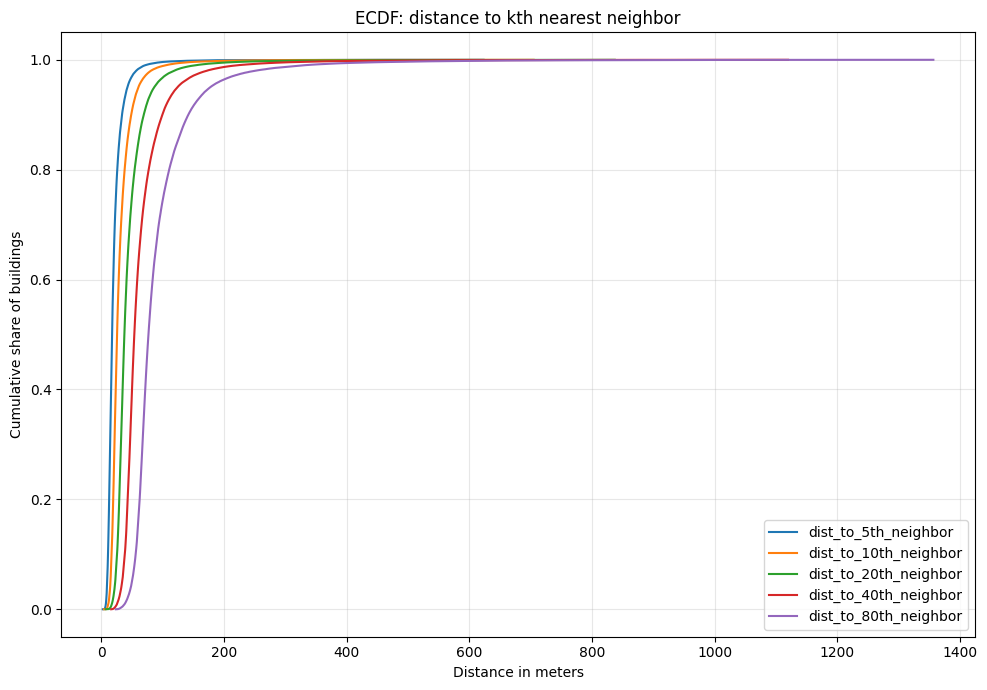

Saved: E:\World Bank deliverbale 1\knn\exploratory_plots\ecdf_distance_to_kth_neighbor.png


In [11]:
plt.figure(figsize=(10, 7))

for col in dist_cols:
    vals = plot_df_sample[col].dropna().sort_values().values
    y = np.arange(1, len(vals) + 1) / len(vals)
    plt.plot(vals, y, label=col)

plt.xlabel("Distance in meters")
plt.ylabel("Cumulative share of buildings")
plt.title("ECDF: distance to kth nearest neighbor")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

out_png = os.path.join(plot_folder, "ecdf_distance_to_kth_neighbor.png")
plt.savefig(out_png, dpi=200)
plt.show()

print("Saved:", out_png)

# Log-x ECDF:

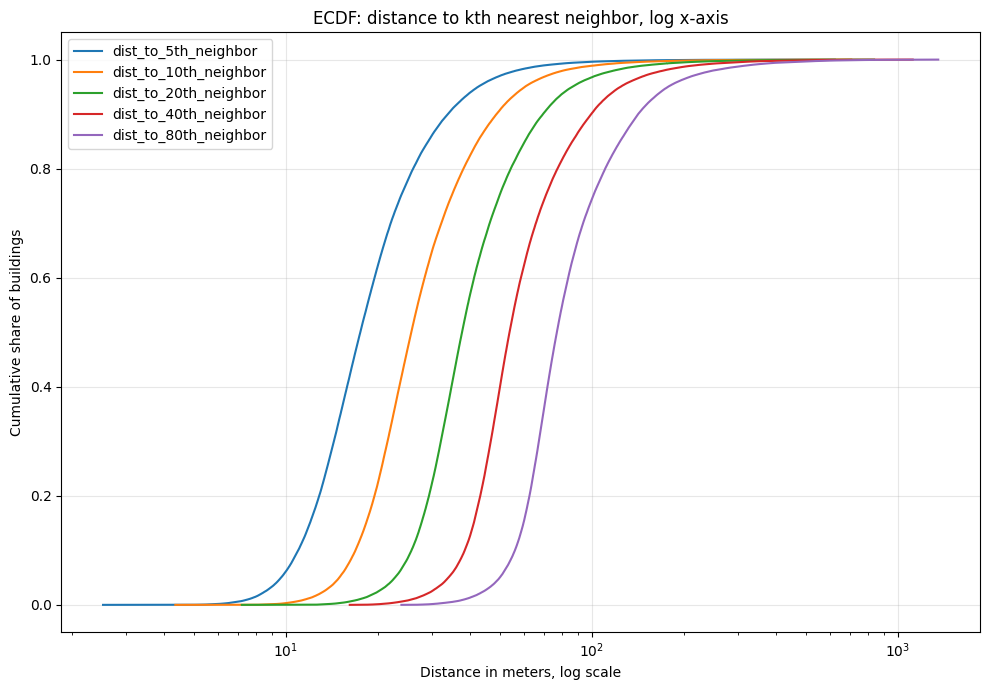

Saved: E:\World Bank deliverbale 1\knn\exploratory_plots\ecdf_logx_distance_to_kth_neighbor.png


In [12]:
plt.figure(figsize=(10, 7))

for col in dist_cols:
    vals = plot_df_sample[col].dropna()
    vals = vals[vals > 0].sort_values().values
    y = np.arange(1, len(vals) + 1) / len(vals)
    plt.plot(vals, y, label=col)

plt.xscale("log")
plt.xlabel("Distance in meters, log scale")
plt.ylabel("Cumulative share of buildings")
plt.title("ECDF: distance to kth nearest neighbor, log x-axis")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

out_png = os.path.join(plot_folder, "ecdf_logx_distance_to_kth_neighbor.png")
plt.savefig(out_png, dpi=200)
plt.show()

print("Saved:", out_png)

# Cell 10 — Scatterplots comparing local versus broader spacing

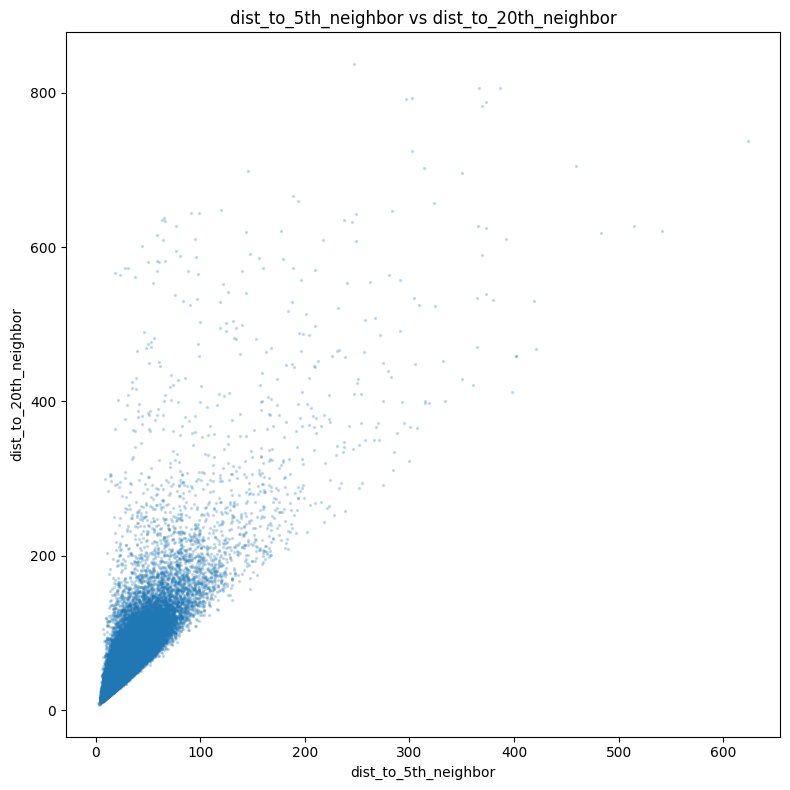

Saved: E:\World Bank deliverbale 1\knn\exploratory_plots\scatter_dist_to_5th_neighbor_vs_dist_to_20th_neighbor.png


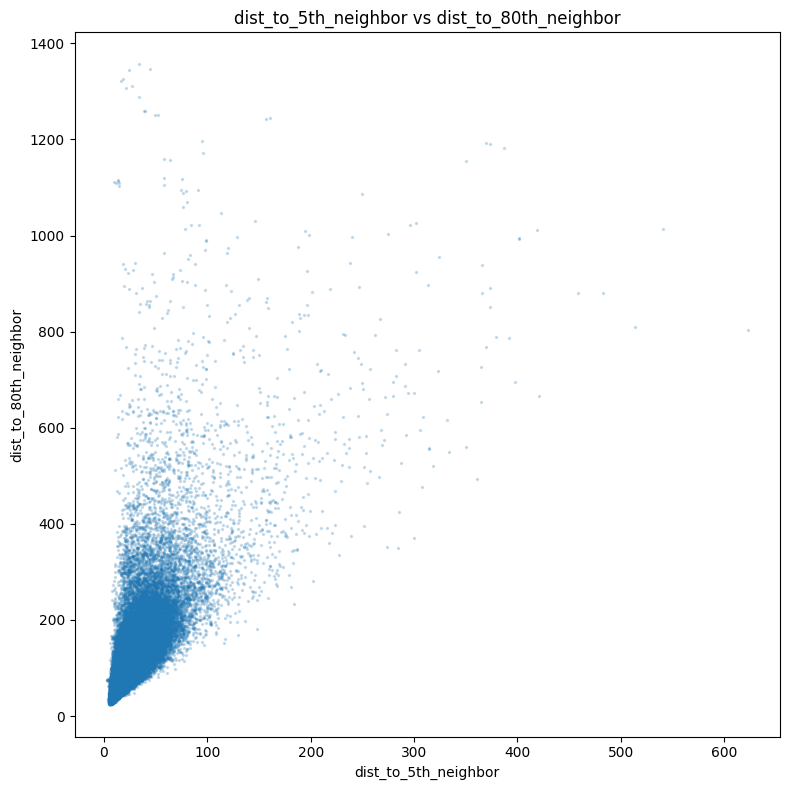

Saved: E:\World Bank deliverbale 1\knn\exploratory_plots\scatter_dist_to_5th_neighbor_vs_dist_to_80th_neighbor.png


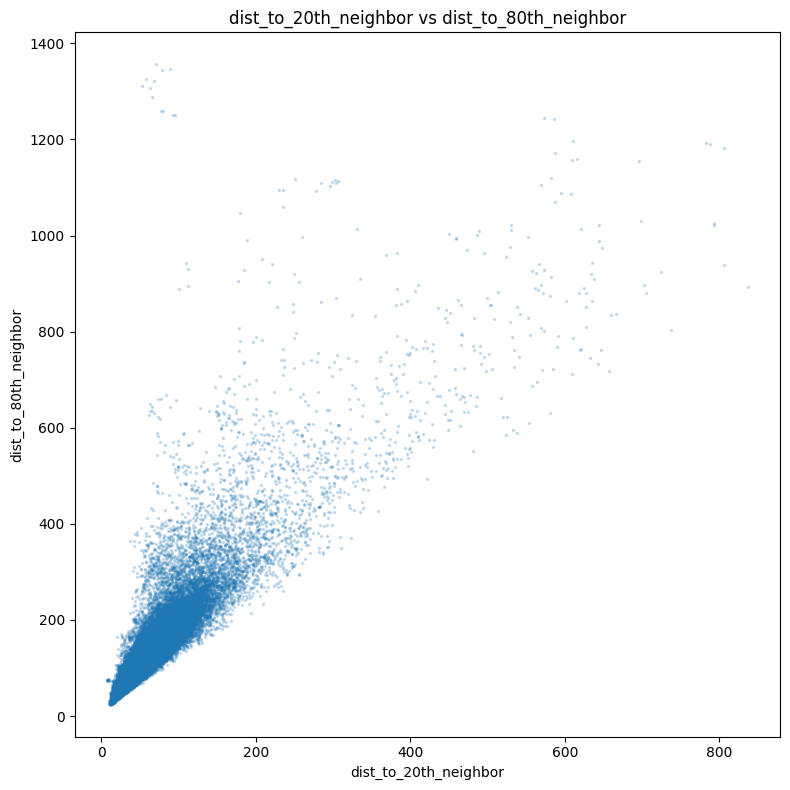

Saved: E:\World Bank deliverbale 1\knn\exploratory_plots\scatter_dist_to_20th_neighbor_vs_dist_to_80th_neighbor.png


In [13]:
scatter_pairs = [
    ("dist_to_5th_neighbor", "dist_to_20th_neighbor"),
    ("dist_to_5th_neighbor", "dist_to_80th_neighbor"),
    ("dist_to_20th_neighbor", "dist_to_80th_neighbor"),
]

for xcol, ycol in scatter_pairs:
    if xcol not in plot_df_sample.columns or ycol not in plot_df_sample.columns:
        continue

    temp = plot_df_sample[[xcol, ycol]].dropna()

    plt.figure(figsize=(8, 8))
    plt.scatter(temp[xcol], temp[ycol], s=2, alpha=0.2)
    plt.xlabel(xcol)
    plt.ylabel(ycol)
    plt.title(f"{xcol} vs {ycol}")
    plt.tight_layout()

    out_png = os.path.join(plot_folder, f"scatter_{xcol}_vs_{ycol}.png")
    plt.savefig(out_png, dpi=200)
    plt.show()

    print("Saved:", out_png)

# Log-log versions:

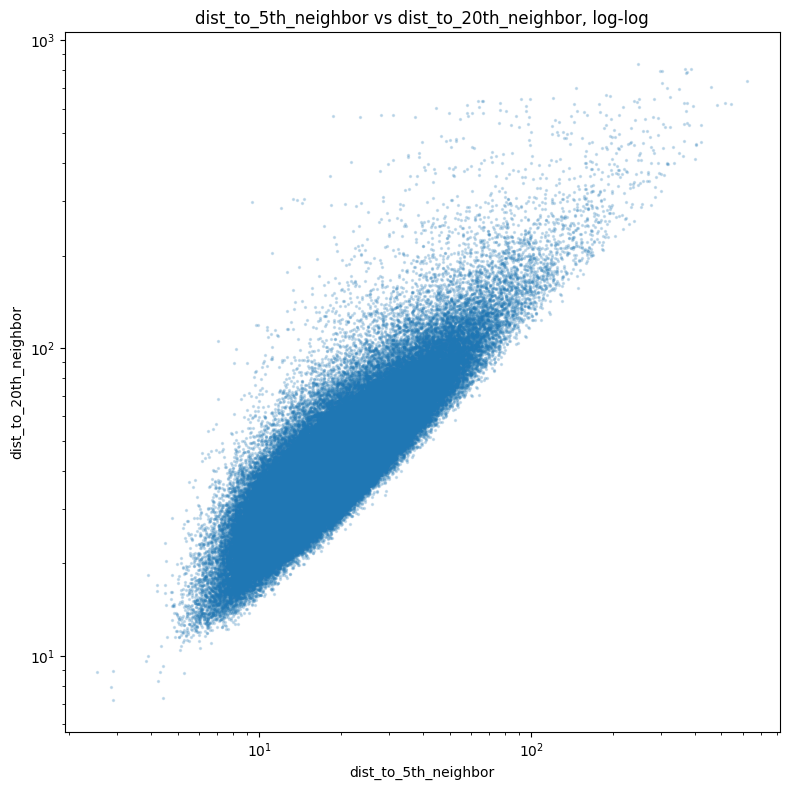

Saved: E:\World Bank deliverbale 1\knn\exploratory_plots\scatter_loglog_dist_to_5th_neighbor_vs_dist_to_20th_neighbor.png


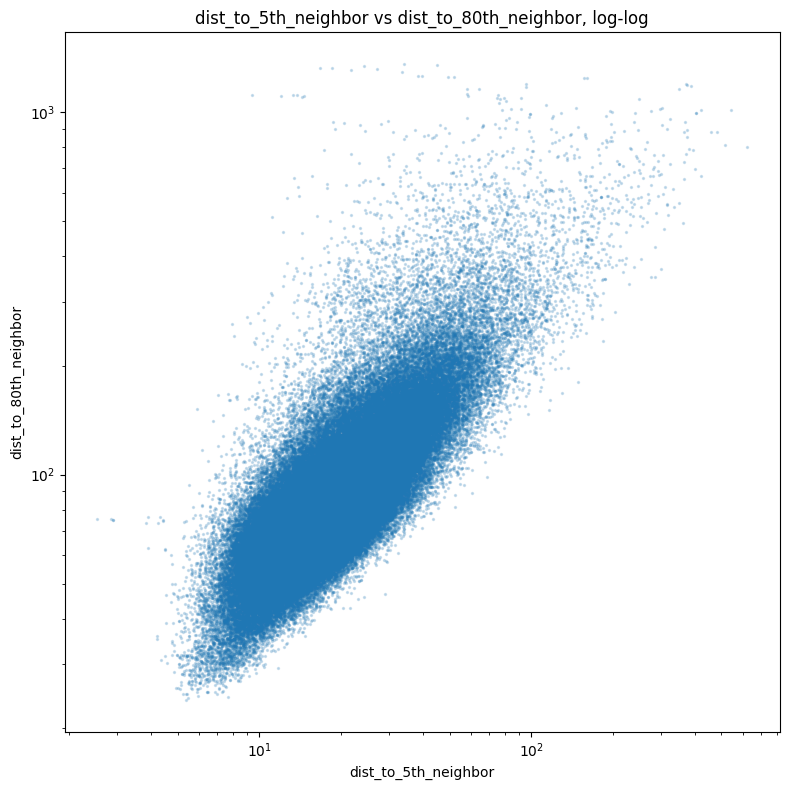

Saved: E:\World Bank deliverbale 1\knn\exploratory_plots\scatter_loglog_dist_to_5th_neighbor_vs_dist_to_80th_neighbor.png


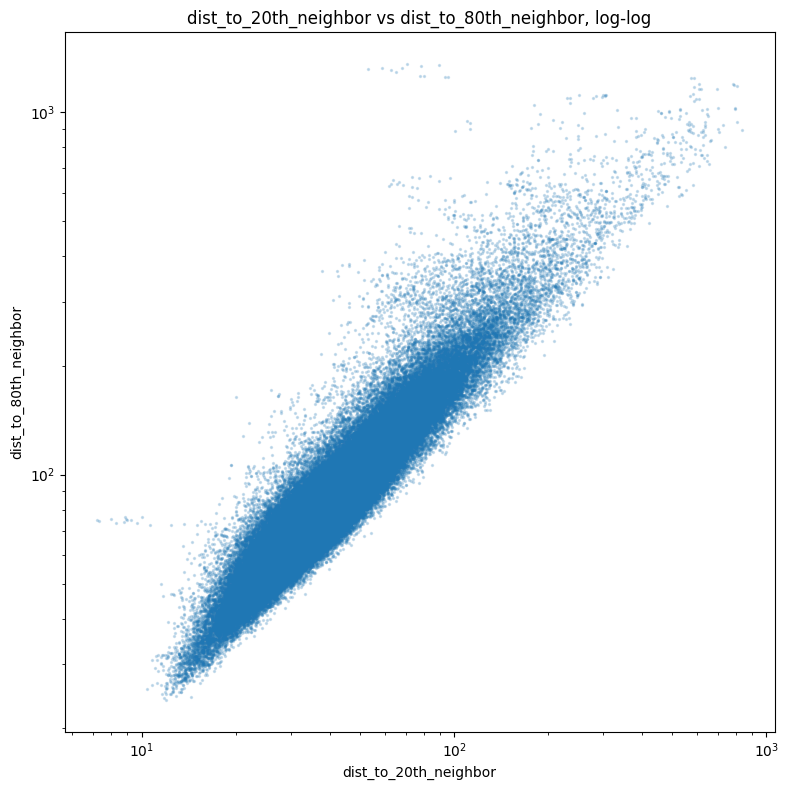

Saved: E:\World Bank deliverbale 1\knn\exploratory_plots\scatter_loglog_dist_to_20th_neighbor_vs_dist_to_80th_neighbor.png


In [14]:
for xcol, ycol in scatter_pairs:
    if xcol not in plot_df_sample.columns or ycol not in plot_df_sample.columns:
        continue

    temp = plot_df_sample[[xcol, ycol]].dropna()
    temp = temp[(temp[xcol] > 0) & (temp[ycol] > 0)]

    plt.figure(figsize=(8, 8))
    plt.scatter(temp[xcol], temp[ycol], s=2, alpha=0.2)
    plt.xscale("log")
    plt.yscale("log")
    plt.xlabel(xcol)
    plt.ylabel(ycol)
    plt.title(f"{xcol} vs {ycol}, log-log")
    plt.tight_layout()

    out_png = os.path.join(plot_folder, f"scatter_loglog_{xcol}_vs_{ycol}.png")
    plt.savefig(out_png, dpi=200)
    plt.show()

    print("Saved:", out_png)

# Cell 11 — Create spacing-ratio variables

In [15]:
ratio_df = wide_df.copy()

if "dist_to_5th_neighbor" in ratio_df.columns and "dist_to_80th_neighbor" in ratio_df.columns:
    ratio_df["ratio_k80_to_k5"] = ratio_df["dist_to_80th_neighbor"] / ratio_df["dist_to_5th_neighbor"]

if "dist_to_20th_neighbor" in ratio_df.columns and "dist_to_80th_neighbor" in ratio_df.columns:
    ratio_df["ratio_k80_to_k20"] = ratio_df["dist_to_80th_neighbor"] / ratio_df["dist_to_20th_neighbor"]

if "dist_to_5th_neighbor" in ratio_df.columns and "dist_to_20th_neighbor" in ratio_df.columns:
    ratio_df["ratio_k20_to_k5"] = ratio_df["dist_to_20th_neighbor"] / ratio_df["dist_to_5th_neighbor"]

ratio_cols = [c for c in ratio_df.columns if c.startswith("ratio_")]

ratio_csv = os.path.join(summary_csv_folder, "knn_summary_all_k_with_ratios.csv")
ratio_df.to_csv(ratio_csv, index=False)

print("Created ratio columns:", ratio_cols)
print("Exported:", ratio_csv)

ratio_df[ratio_cols].describe(
    percentiles=[0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
).T

Created ratio columns: ['ratio_k80_to_k5', 'ratio_k80_to_k20', 'ratio_k20_to_k5']
Exported: E:\World Bank deliverbale 1\knn\summary_csvs\knn_summary_all_k_with_ratios.csv


,count,mean,std,min,1%,5%,10%,25%,50%,75%,90%,95%,99%,max
ratio_k80_to_k5,578379.0,4.717170,1.664399,1.134425,2.485149,2.958912,3.228664,3.737907,4.437486,5.337015,6.412825,7.261207,9.905666,118.797639
ratio_k80_to_k20,578379.0,2.101726,0.373236,1.059672,1.532121,1.680086,1.754165,1.884978,2.049236,2.249927,2.487127,2.672520,3.219553,27.357101
ratio_k20_to_k5,578379.0,2.239570,0.620638,1.035206,1.416200,1.566373,1.658740,1.846565,2.120435,2.490132,2.932333,3.273389,4.209757,31.972150


# Plot ratios

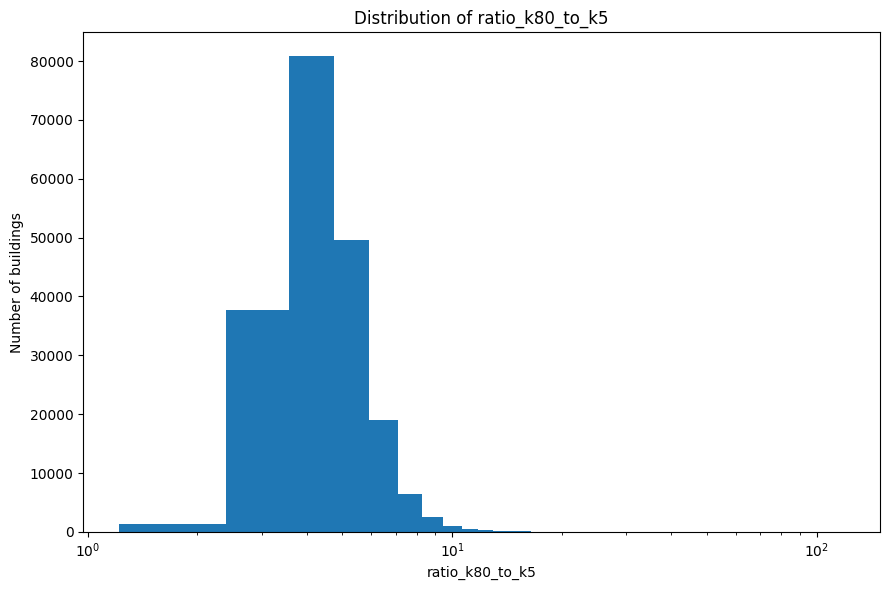

Saved: E:\World Bank deliverbale 1\knn\exploratory_plots\hist_logx_ratio_k80_to_k5.png


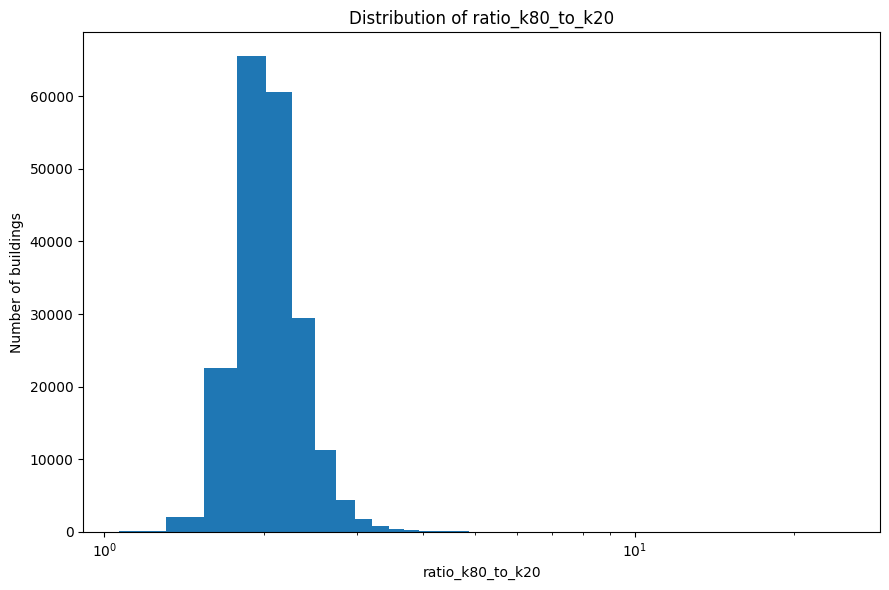

Saved: E:\World Bank deliverbale 1\knn\exploratory_plots\hist_logx_ratio_k80_to_k20.png


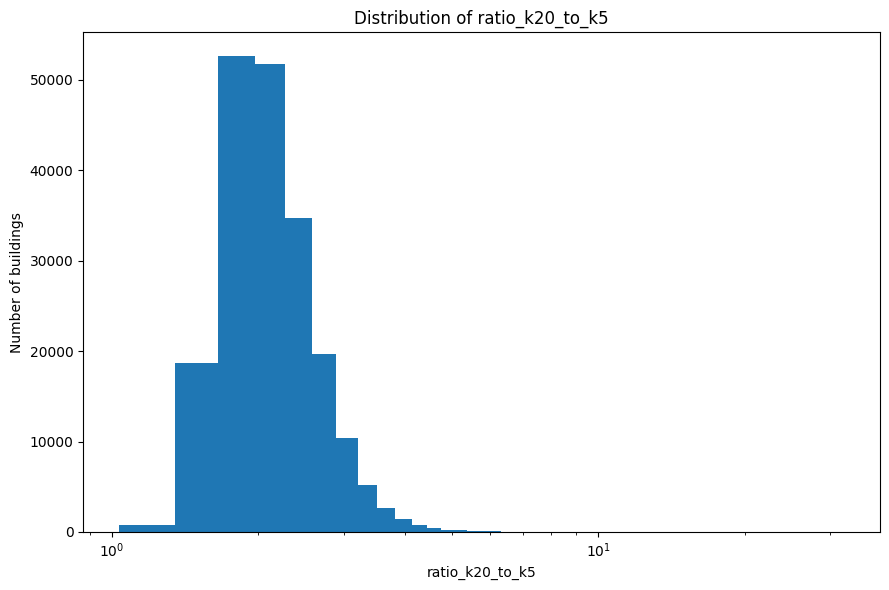

Saved: E:\World Bank deliverbale 1\knn\exploratory_plots\hist_logx_ratio_k20_to_k5.png


In [16]:
if len(ratio_df) > sample_size:
    ratio_sample = ratio_df.sample(sample_size, random_state=42)
else:
    ratio_sample = ratio_df

for col in ratio_cols:
    vals = ratio_sample[col].replace([np.inf, -np.inf], np.nan).dropna()
    vals = vals[vals > 0]

    plt.figure(figsize=(9, 6))
    plt.hist(vals, bins=100)
    plt.xscale("log")
    plt.xlabel(col)
    plt.ylabel("Number of buildings")
    plt.title(f"Distribution of {col}")
    plt.tight_layout()

    out_png = os.path.join(plot_folder, f"hist_logx_{col}.png")
    plt.savefig(out_png, dpi=200)
    plt.show()

    print("Saved:", out_png)